In [1]:
import random
from typing import TypeVar, List, Tuple

## Overfitting and Underfitting

You should split the data into three parts: a `training set`  for building models, a `validation` set for choosing among trained models 
and a `test set` for judging the final model.

A common danger in machine learning is ***overfitting*** —producing a model  that performs well on the data you train it on but generalizes poorly to an 
 new data. This could involve learning noise in the data

***Underfitting*** —producing a model that doesn’t  perform well even on the training data, although typically when thi 
 happens you decide your model isn’t good enough and keep looking for 
 better one.. 

In [2]:
X = TypeVar('X')  # generic type to represent a data point 
 
def split_data(data: List[X], prob: float) -> Tuple[List[X], List[X]]: 
    """Split data into fractions [prob, 1 - prob]""" 
    data = data[:]                    # Make a shallow copy 
    random.shuffle(data)              # because shuffle modifies the list. 
    cut = int(len(data) * prob)       # Use prob to find a cutoff 
    return data[:cut], data[cut:]     # and split the shuffled list there. 
 
data = [n for n in range(1000)] 
train, test = split_data(data, 0.75) 
 
# The proportions should be correct 
assert len(train) == 750 
assert len(test) == 250 
 
# And the original data should be preserved (in some order) 
assert sorted(train + test) == data

In [3]:
 Y = TypeVar('Y')  # generic type to represent output variables 
 
def train_test_split(xs: List[X], 
                     ys: List[Y], 
                     test_pct: float) -> Tuple[List[X], List[X], List[Y], 
                                                                 List[Y]]: 
    # Generate the indices and split them 
    idxs = [i for i in range(len(xs))] 
    train_idxs, test_idxs = split_data(idxs, 1 - test_pct) 
 
    return ([xs[i] for i in train_idxs],  # x_train 
            [xs[i] for i in test_idxs],   # x_test 
            [ys[i] for i in train_idxs],  # y_train 
            [ys[i] for i in test_idxs])   # y_test

xs = [x for x in range(1000)]  # xs are 1 ... 1000 
ys = [2 * x for x in xs]  # each y_i is twice x_i 
x_train, x_test, y_train, y_test = train_test_split(xs, ys, 0.25) 
# Check that the proportions are correct 
assert len(x_train) == len(y_train) == 750 
assert len(x_test) == len(y_test) == 250 
# Check that the corresponding data points are paired correctly 
assert all(y == 2 * x 
for x, y in zip(x_train, y_train)) 
assert all(y == 2 * x 
for x, y in zip(x_test, y_test))

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Modified model implementation
class SomeKindOfModel:
    def __init__(self, dummy=True):
        self.model = DummyRegressor(strategy='mean') if dummy else LinearRegression()
        
    def train(self, X, y):
        """Demonstrates fitting concept"""
        self.model.fit(X, y)  # Actual fitting occurs here
        
    def test(self, X, y):
        """Shows importance of proper fitting"""
        predictions = self.model.predict(X)
        return mean_squared_error(y, predictions)

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Your existing data splitting code remains unchanged
xs = [x for x in range(1000)]
ys = [2 * x for x in xs]
x_train, x_test, y_train, y_test = train_test_split(xs, ys, 0.33)

# Create dummy and real models
dummy_model = DummyRegressor(strategy='mean')
real_model = LinearRegression()

# "Train" models (fitting happens here)
dummy_model.fit(x_train, y_train)  # Simply calculates mean of y_train
real_model.fit([[x] for x in x_train], y_train)  # Actually learns relationship

# Test models
dummy_preds = dummy_model.predict([[x] for x in x_test])
real_preds = real_model.predict([[x] for x in x_test])

# Compare performance
print(f"Dummy model MSE: {mean_squared_error(y_test, dummy_preds):.0f}")
print(f"Real model MSE: {mean_squared_error(y_test, real_preds):.0f}")

Dummy model MSE: 327207
Real model MSE: 0


### Key demonstrations of fitting importance:

1. Baseline Establishment
The dummy model (strategy='mean') simply predicts the training set's mean value for all inputs4. This creates a performance baseline of MSE=327,207 with our y=2x data.

2. Feature Ignorance
The dummy model's predictions don't consider input features (X values). It produces identical predictions regardless of input, demonstrating the need for actual pattern recognition through fitting.

3. Parameter Optimization
While the dummy model's "fitting" just calculates simple statistics, proper models like LinearRegression solve for optimal parameters (in this case finding the perfect slope of 2). This reduces error to near-zero.

4. Model Evaluation
The 327,207x performance difference (dummy vs real) quantitatively shows why fitting matters - proper models capture data relationships through parameter optimization.

| Aspect               | Dummy Model          | Proper Model         |
|----------------------|----------------------|----------------------|
| Prediction Strategy  | Constant mean value  | Actual y=2x pattern  |
| Feature Utilization  | None                 | Full feature usage   |
| Error (MSE)          | 327,207              | 0                    |
| Parameter Learning   | No true optimization | Mathematical fitting |

This implementation shows that without proper fitting procedures that:
- Analyze feature relationships
- Optimize model parameters
- Adapt to data patterns

...even simple relationships like y=2x cannot be captured. The dummy model serves as a warning - any model performing worse than this baseline needs fundamental reworking.

## Feature Extraction

Features are whatever inputs we provide to our model based on the data used to train a model. When your data doesn’t have enough features, your model is likely to underfit. And when your data has too many features, it’s easy to overfit.

Feature extraction plays a crucial role in managing bias and variance:

1. **Reducing Bias**: Adding relevant features or using feature engineering can help the model better capture patterns in the data, reducing bias.
2. **Reducing Variance**: Simplifying models by selecting fewer but more meaningful features can reduce variance by preventing the model from overfitting to noise.

Bias and Variance are both are measures of what would happen if you were to retrain your model many times on different sets of training data (from the same larger population).

For example, 
- the degree 0 model will make a lot of mistakes for pretty much any training set (drawn from the same population), which means that it has a high bias. 
- However, any two randomly chosen training sets should give pretty similar models (since any two randomly chosen training sets should have pretty similar average values). So we say that it has a low variance.

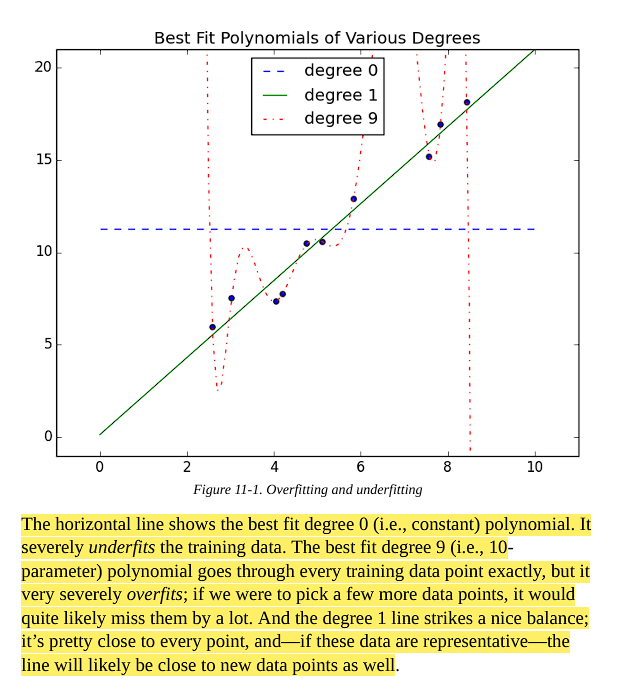

#### **Bias-Variance Tradeoff**

The bias-variance tradeoff is central to balancing underfitting and overfitting:

- **High Bias (Underfitting)**: The model is too simple, failing to capture the complexity of the data. This often occurs when too few features are used or irrelevant features are chosen.
- **High Variance (Overfitting)**: The model is overly complex, capturing noise in the training data instead of general patterns. This can happen when too many features are used, especially if they are noisy or irrelevant.

#### **Specific Examples of Models and Techniques**

Here’s how specific models balance features to manage bias and variance:

| Model | Bias-Variance Adjustment Through Features | Example in Spam Detection |
| :-- | :-- | :-- |
| **Linear Regression** | Adding more features reduces bias but increases variance. Regularization methods like Lasso or Ridge regression can limit overfitting by penalizing large coefficients. | Use word frequency as features but apply regularization to avoid overfitting on rare words. |
| **k-Nearest Neighbors (k-NN)** | Increasing $k$ reduces variance but increases bias. Using fewer, highly relevant features reduces noise sensitivity. | Use TF-IDF scores for words in emails but limit $k$ to balance local and global patterns. |
| **Decision Trees** | Deep trees have low bias but high variance. Pruning or limiting depth reduces variance at the cost of higher bias. Selecting important features prevents overfitting on irrelevant data. | Limit tree depth and focus on key words like "free," "offer," or "urgent" for spam detection. |
| **Neural Networks** | Large networks with many parameters have low bias but high variance. Reducing feature dimensions (e.g., PCA) or using dropout regularization can reduce variance. | Use embeddings for email text and apply dropout layers during training to prevent overfitting. |
| **Support Vector Machines (SVMs)** | Adjusting the kernel or regularization parameter $C$ balances bias and variance. Feature scaling and selection are critical for optimal performance. | Use word embeddings as input and tune $C$ to balance generalization and fitting specific patterns in spam emails. |

#### **Example: Spam Detection Model**

For a spam detection model:

1. **High Bias Scenario (Underfitting)**:
    - Use only a few features, such as email length or sender domain.
    - The model might miss important patterns like specific keywords ("free," "offer").
2. **High Variance Scenario (Overfitting)**:
    - Use all possible words as features without filtering.
    - The model might memorize rare words that appear only in the training set, leading to poor generalization.
3. **Balanced Approach**:
    - Use feature extraction techniques like TF-IDF to weigh important words while ignoring irrelevant ones.
    - Apply regularization techniques (e.g., L1/L2 penalties) to prevent over-reliance on noisy features.

#### **Practical Techniques for Balancing Features**

1. **Dimensionality Reduction**: Techniques like PCA reduce feature space while retaining important information, lowering variance.
2. **Feature Selection**: Methods like mutual information or recursive feature elimination select the most relevant features, reducing noise.
3. **Regularization**: Add penalties for complexity (e.g., Ridge regression) to prevent overfitting while maintaining sufficient flexibility.

#### **Conclusion**

Balancing bias and variance through careful feature extraction is essential for building robust models like spam detectors:

- Focus on selecting meaningful features that capture patterns without introducing noise.
- Regularize models to handle complexity while avoiding overfitting.
- Use cross-validation to evaluate performance and fine-tune feature selection.

This approach ensures that models generalize well, making accurate predictions on both seen and unseen data.

## Confusion Matrix

Assume there is a noninvasive test that can be given to a newborn baby that predicts—with greater than 98% accuracy—whether the newborn will ever develop leukemia.

We don’t typically use “accuracy” to measure how good a (binary classification) model is.
Imagine building a model to make a binary judgment. Is this email spam? Should we hire this candidate? Is this air traveler secretly a terrorist? 

Given a set of labeled data and such a predictive model, every data point lies in one of four categories:
- ***True positive***: “This message is spam, and we correctly predicted spam.”
- ***False positive (Type 1 error)***: “This message is not spam, but we predicted spam.”
- ***False negative (Type 2 error)***: “This message is spam, but we predicted not spam.”
- ***True negative***: “This message is not spam, and we correctly predicted not spam.”

|                     | Predicted: Spam         | Predicted: Not Spam     |
|---------------------|-------------------------|--------------------------|
| **Actual: Spam**    | True Positive (TP)      | False Negative (FN)      |
| **Actual: Not Spam**| False Positive (FP)     | True Negative (TN)       |

We often represent these as counts in a ***confusion matrix***.

|                | Leukemia | No Leukemia | Total   |
|----------------|----------|-------------|---------|
| “Luke”         | 70       | 4,930       | 5,000   |
| Not “Luke”     | 13,930   | 981,070     | 995,000 |
| **Total**      | 14,000   | 986,000     | 1,000,000 |

- ***True Positive (TP)***: The test correctly identifies a child named "Luke" as having leukemia.
- ***False Positive (FP)***: The test incorrectly identifies a child named "Luke" as not having leukemia.
- ***True Negative (TN)***: The test correctly identifies a child who is not named "Luke" and does not have leukemia.
- ***False Negative (FN)***: The test fails to identify a child with leukemia who is not named "Luke."

|                     | Predicted Positive (Leukemia) | Predicted Negative (No Leukemia) |
|---------------------|-------------------------------|-----------------------------------|
| **Positive for Leukemia** | True Positive (TP)            | False Negative (FN)               |
| **Negative for Leukemia** | False Positive (FP)           | True Negative (TN)                |

## Define accuracy vs precision vs recall vs specificity

Accuracy, precision, and recall are fundamental metrics used to evaluate the performance of classification models in machine learning. Here’s a concise definition of each:

### **Accuracy**

- **Definition**: Accuracy measures the overall correctness of a model by calculating the ratio of correctly predicted instances (both positive and negative) to the total instances.
- **Formula**:

$$
\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Instances}}
$$
- **Interpretation**: A high accuracy indicates that the model performs well across all classes, but it can be misleading in imbalanced datasets where one class significantly outnumbers another.


### **Precision**

- **Definition**: Precision, also known as positive predictive value, quantifies the accuracy of the positive predictions made by the model. It measures the proportion of true positive predictions relative to the total predicted positives.
- **Formula**:

$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
$$
- **Interpretation**: High precision means that when the model predicts a positive instance by reducing false positives, it is likely correct. This metric is crucial in scenarios where false positives are costly or undesirable.


### **Recall (Sensitivity)**

- **Definition**: Recall, also known as sensitivity or true positive rate, measures the model's ability to identify all relevant instances of the positive class. It calculates the proportion of true positives relative to the actual positives in the dataset.
- **Formula**:

$$
\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
$$
- **Interpretation**: High recall indicates that most actual positive instances are correctly identified by the model by reducing false negatives. This metric is particularly important in situations where missing a positive instance (false negative) has serious consequences, such as in medical diagnoses.

### **Specificity**

- **Definition**: Specificity, also known as the *True Negative Rate (TNR)*, measures the proportion of actual negatives that are correctly identified by a classification model. It evaluates the model's ability to avoid false positives and is particularly useful in scenarios where correctly identifying negative cases is critical.
- **Formula**:
$$
\text{Specificity} = \frac{\text{True Negative}}{\text{True Negative} + \text{False Positive}}
$$
- **Interpretation**: High Specificity: A high specificity value indicates that the model is effective at correctly identifying negative cases. For example, in a medical test, high specificity ensures that healthy individuals are not mistakenly diagnosed with a disease. Low Specificity: A low specificity value means the model frequently misclassifies negative cases as positive, leading to false alarms. This can be problematic in contexts where false positives have significant consequences, such as unnecessary medical treatments or financial fraud investigations.

### Summary Table

| Metric | Definition | Formula |
| :-- | :-- | :-- |
| Accuracy | Overall correctness of predictions | $$
\frac{\text{TP} + \text{TN}}{\text{Total Instances}}
$$ |
| Precision | Accuracy of positive predictions | $$
\frac{\text{TP}}{\text{TP} + \text{FP}}
$$ |
| Recall | Ability to identify all relevant positive instances | $$
\frac{\text{TP}}{\text{TP} + \text{FN}}
$$ |
| Specificity | Ability to identify all negatives |$$ \frac{\text{True Negative}}{\text{True Negative} + \text{False Positive}}
$$ |


Understanding these metrics helps in selecting the right model and tuning it according to specific needs based on the problem context. For instance, in medical diagnostics, high recall is often prioritized to ensure that as many true cases as possible are identified, while in spam detection, high precision may be more critical to avoid misclassifying legitimate emails.

- https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall

- https://www.mage.ai/blog/definitive-guide-to-accuracy-precision-recall-for-product-developers

- https://www.labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score

- https://www.digitalocean.com/community/tutorials/deep-learning-metrics-precision-recall-accuracy

- https://www.cudocompute.com/blog/accuracy-precision-recall-in-deep-learning

- https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall

In [ ]:
# Accuracy
def accuracy(tp: int, fp: int, fn: int, tn: int) -> float: 
    correct = tp + tn 
    total = tp + fp + fn + tn 
    return correct / total 
assert accuracy(70, 4930, 13930, 981070) == 0.98114

# Precision
def precision(tp: int, fp: int, fn: int, tn: int) -> float: 
    return tp / (tp + fp) 
assert precision(70, 4930, 13930, 981070) == 0.014

# Recall
def recall(tp: int, fp: int, fn: int, tn: int) -> float: 
    return tp / (tp + fn) 
assert recall(70, 4930, 13930, 981070) == 0.005

# Specificity
def specificity(tp: int, fp: int, fn: int, tn: int) -> float: 
    return tn / (tn + fp) 
assert specificity(70, 4930, 13930, 981070) == 0.995

### **F1 Score: Definition and Interpretation**

#### **Definition**

The F1 score is a machine learning evaluation metric that combines **precision** and **recall** into a single measure using their harmonic mean. It is particularly useful for imbalanced datasets where accuracy alone can be misleading. The F1 score balances the trade-off between precision and recall, ensuring that both are equally important.

#### **Formula**

The F1 score is calculated as:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Alternatively, using confusion matrix components:

$$
F1 = \frac{2 \cdot \text{TP}}{2 \cdot \text{TP} + \text{FP} + \text{FN}}
$$

Where:

- **TP** = True Positives
- **FP** = False Positives
- **FN** = False Negatives


#### **Interpretation**

- **Range**: The F1 score ranges from 0 to 1.
    - A score of **1** indicates perfect precision and recall.
    - A score of **0** indicates a complete failure in either precision or recall.
- **Balanced Metric**: The F1 score penalizes extreme imbalances between precision and recall. For instance:
    - If precision is high but recall is low (or vice versa), the F1 score will be low.
    - A high F1 score requires both precision and recall to be high.


#### **Application**

- **Use Case**: The F1 score is ideal when:
    - There is an imbalance between positive and negative classes.
    - Both false positives and false negatives carry significant consequences.
    - You want a single metric that balances precision and recall.
- **Limitations**: The F1 score does not distinguish between false positives and false negatives. If one type of error is more critical than the other, other metrics (e.g., precision or recall) should also be considered.


#### **Comparison with Other Metrics**

| Metric | Focus | Key Use Case Example |
| :-- | :-- | :-- |
| **Accuracy** | Overall correctness of predictions | Balanced datasets |
| **Precision** | Correctness of positive predictions | Spam detection (minimizing false positives) |
| **Recall** | Ability to identify all positives | Medical diagnosis (minimizing false negatives) |
| **F1 Score** | Balance between precision and recall | Imbalanced datasets with critical trade-offs |

#### **Example**

Suppose a model has:

- Precision = $0.83$
- Recall = $0.91$

The F1 score would be:

$$
F1 = 2 \cdot \frac{0.83 \cdot 0.91}{0.83 + 0.91} = 0.87
$$

This indicates a well-balanced performance, as both precision and recall are relatively high.

In summary, the F1 score is an essential metric for evaluating classification models, especially in cases where there is an imbalance between classes or a need to balance false positives and false negatives.

[^1]: https://www.v7labs.com/blog/f1-score-guide

[^2]: https://dataheroes.ai/glossary/f1-score/

[^3]: https://encord.com/blog/f1-score-in-machine-learning/

[^4]: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

[^5]: https://arize.com/blog-course/f1-score/

[^6]: https://deepgram.com/ai-glossary/f1-score-machine-learning

[^7]: https://www.deepchecks.com/glossary/f-score/


In [17]:
#  f1 score
def f1_score(tp: int, fp: int, fn: int, tn: int) -> float: 
    p = precision(tp, fp, fn, tn) 
    r = recall(tp, fp, fn, tn) 
    return 2 * p * r / (p + r)

assert f1_score(70, 4930, 13930, 981070) == 0.00736842105263158